In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from gstools import SRF, Gaussian
from gstools.random import MasterRNG

In [3]:
from scipy import integrate

In [4]:
m1 = 192
m2 = 1000
n = 200

In [5]:
x = np.linspace(0, 1, m2)

In [6]:
import scipy.io as sio
import os

#cwd = os.getcwd()
#os.chdir(cwd)
path = '/home/saumya/NeuralN/deepxsede/spyder tries'
os.environ['PATH'] += ':'+path


mat = sio.loadmat('data_4_training_Ef_1000.mat')    #loading data sets with prob >= 0.99 and not noisy
V = mat['V_train']
Ef = mat['Ef_train']

In [7]:
print(np.shape(V))
print(np.shape(V[1,:]))
print(np.shape(Ef))
print(np.shape(Ef[1,:]))

(36118, 192)
(192,)
(36118, 1000)
(1000,)


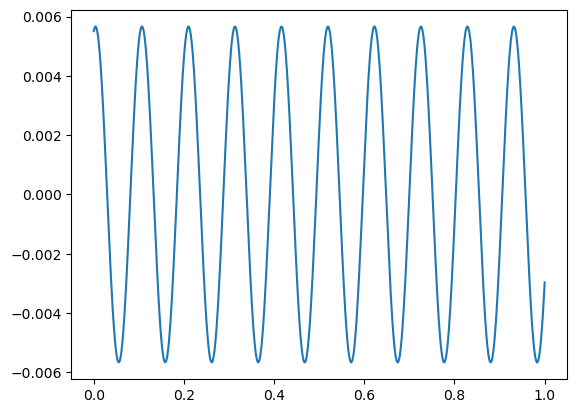

In [9]:
plt.plot(x, Ef[1, :])

In [16]:
# US -> m*n = 11000 ==> us (11000,100)
# xs -> (11000, 1)#m = 100
#n = 110

#def integrate_data(m1=m1, m2=m2, n=n, x=x, U=U, S=S):
# ss -> (11000, 1)

In [17]:
#def integrate_data(m=m, n=n, x=x, U=U, S=S):
#    us = np.zeros((m*n, m))
#    xs = np.zeros((m*n, 1))
#    ss = np.zeros((m*n, 1))
#    for i in range(n):
#        for j in range(m2):
#            us[i*m+j, :] = U[:, i]
#            xs[i*m+j, :] = x[j]
#            ss[i*m+j, :] = S[j, i]
#    return us, xs, ss


def integrate_data(m1=m1, m2=m2, n=n, x=x, U=V, S=Ef):
    us = np.zeros((m2*n, m1))
    xs = np.zeros((m2*n, 1))
    ss = np.zeros((m2*n, 1))
    for i in range(n):
        for j in range(m2):
            us[i*m2+j, :] = V[i, :]
            xs[i*m2+j, :] = x[j]
            ss[i*m2+j, :] = Ef[j, i]
    return us, xs, ss

In [18]:
us, xs, ss = integrate_data()
print(us.shape, xs.shape, ss.shape)

(200000, 192) (200000, 1) (200000, 1)


In [19]:
def batch_dataset(batch_size, m1=m1, m2=m2, n=n, x=x, U=V, S=Ef, ratio=0.9):
    us, xs, ss = integrate_data(m1, m2, n, x, U=V, S=Ef)
    train_size = int(len(us)*ratio)
    us_train = us[:train_size]
    xs_train = xs[:train_size]
    ss_train = ss[:train_size]

    us_test = us[train_size:]
    xs_test = xs[train_size:]
    ss_test = ss[train_size:]

    us_train = torch.tensor(us_train, dtype=torch.float32)
    xs_train = torch.tensor(xs_train, dtype=torch.float32)
    ss_train = torch.tensor(ss_train, dtype=torch.float32)
    train_dataset = torch.utils.data.TensorDataset(us_train, xs_train, ss_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    us_test = torch.tensor(us_test, dtype=torch.float32)
    xs_test = torch.tensor(xs_test, dtype=torch.float32)
    ss_test = torch.tensor(ss_test, dtype=torch.float32)
    test_dataset = torch.utils.data.TensorDataset(us_test, xs_test, ss_test)
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

    return train_dataloader, test_dataloader

In [20]:
train_data, test_data = batch_dataset(batch_size=32, ratio=0.9)

In [21]:
#for u_batch, x_batch, s_batch in train_data:
#    print(u_batch, x_batch, s_batch)

In [22]:
class DeepONet(nn.Module):
    def __init__(self, neurons=40, in1=1, in2=1, output_neurons=20):
        super(DeepONet, self).__init__()
        self.in1 = in1
        self.in2 = in2
        self.output_neurons = output_neurons
        self.neurons = neurons

        self.branch = self.branch_network()
        self.trunk = self.trunk_network()

    def branch_network(self):
        branch = nn.Sequential(nn.Linear(self.in1, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.output_neurons))
        return branch


    def trunk_network(self):
        trunk = nn.Sequential(nn.Linear(self.in2, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.neurons), nn.ReLU(),
                               nn.Linear(self.neurons, self.output_neurons))
        return trunk


    def forward(self, x1, x2):
        x1 = self.branch(x1)
        x2 = self.trunk(x2)
        x = torch.einsum("bi, bi-> b", x1, x2)
        x = torch.unsqueeze(x, 1)
        return x


In [23]:
model = DeepONet(neurons = 40, in1 = m1, in2=1)

In [24]:
#model.eval()

In [25]:
def loss(y_pred, y):
    return torch.mean((y_pred - y)**2)

In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [27]:
train_losses = []
epochs = 4000
#epochs = 500
for i in range(epochs):
    l_total = 0
    for u_batch, x_batch, s_batch in train_data:
        model.train()
        optimizer.zero_grad()
        y_pred = model(u_batch, x_batch)

        l = loss(y_pred, s_batch)
        l_total += l.item()
        l.backward()
        optimizer.step()

    l_total = l_total/len(train_data)
    train_losses.append(l_total)

#    print("i: ", i)
    if i%10 == 0:
        print("Epoch:  ", i, "/", epochs, "loss: ", l_total)

    

Epoch:   0 / 500 loss:  6.258341822879932e-05
Epoch:   10 / 500 loss:  2.377683628502483e-05
Epoch:   20 / 500 loss:  2.3772946977826198e-05
Epoch:   30 / 500 loss:  2.3774245997062987e-05
Epoch:   40 / 500 loss:  2.37734859828682e-05
Epoch:   50 / 500 loss:  2.3773193284028418e-05
Epoch:   60 / 500 loss:  2.377727706868124e-05
Epoch:   70 / 500 loss:  2.377569249268466e-05
Epoch:   80 / 500 loss:  2.377502299851686e-05
Epoch:   90 / 500 loss:  2.3774240170152754e-05
Epoch:   100 / 500 loss:  2.3774317333542666e-05
Epoch:   110 / 500 loss:  2.3768830165014758e-05
Epoch:   120 / 500 loss:  2.3772973500146894e-05
Epoch:   130 / 500 loss:  2.3776827909589176e-05
Epoch:   140 / 500 loss:  2.3774468232457164e-05
Epoch:   150 / 500 loss:  2.377608747079244e-05
Epoch:   160 / 500 loss:  2.3772427873013335e-05
Epoch:   170 / 500 loss:  2.3772770477484705e-05
Epoch:   180 / 500 loss:  2.3776592905859514e-05
Epoch:   190 / 500 loss:  2.3769574327323224e-05
Epoch:   200 / 500 loss:  2.37710996990

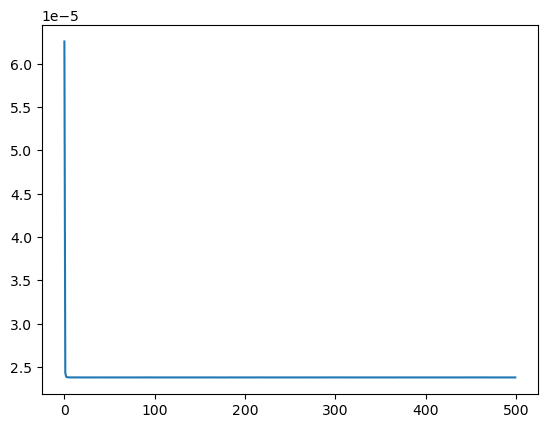

In [28]:
plt.plot(train_losses)

In [29]:
u_t = V[1200,:]
s_t = Ef[1200,:]

In [30]:
model.eval()

DeepONet(
  (branch): Sequential(
    (0): Linear(in_features=192, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=20, bias=True)
  )
  (trunk): Sequential(
    (0): Linear(in_features=1, out_features=40, bias=True)
    (1): ReLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=40, bias=True)
    (5): ReLU()
    (6): Linear(in_features=40, out_features=20, bias=True)
  )
)

In [31]:
u_t_tens = torch.tensor(u_t, dtype = torch.float32)
#print(u_t_tens)
u_t_tens = torch.tensor(u_t, dtype = torch.float32).unsqueeze(0)
#print(u_t_tens)
x_tens = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
#print(x_tens)

In [32]:
print(u_t_tens.shape)

torch.Size([1, 192])


In [33]:
p = model(u_t_tens, x_tens)

In [34]:
print(u_t_tens)

tensor([[-7.4055e-04, -9.2864e-04, -1.1610e-03, -1.4470e-03, -1.7980e-03,
         -2.2273e-03, -2.7508e-03, -3.3870e-03, -4.1577e-03, -5.0881e-03,
         -6.2079e-03, -7.5512e-03, -9.1572e-03, -1.1071e-02, -1.3344e-02,
         -1.6036e-02, -1.9212e-02, -2.2947e-02, -2.7326e-02, -3.2442e-02,
         -3.8400e-02, -4.5315e-02, -5.3314e-02, -6.2536e-02, -7.3134e-02,
         -8.5271e-02, -9.9125e-02, -1.1488e-01, -1.3275e-01, -1.5294e-01,
         -1.7568e-01, -2.0120e-01, -2.2975e-01, -2.6157e-01, -2.9691e-01,
         -3.3605e-01, -3.7923e-01, -4.2672e-01, -4.7874e-01, -5.3556e-01,
         -5.9739e-01, -6.6445e-01, -7.3691e-01, -8.1495e-01, -8.9871e-01,
         -9.8828e-01, -1.0837e+00, -1.1851e+00, -1.2924e+00, -1.4055e+00,
         -1.5244e+00, -1.6488e+00, -1.7787e+00, -1.9137e+00, -2.0536e+00,
         -2.1980e+00, -2.3465e+00, -2.4988e+00, -2.6543e+00, -2.8126e+00,
         -2.9732e+00, -3.1355e+00, -3.2990e+00, -3.4631e+00, -3.6274e+00,
         -3.7911e+00, -3.9538e+00, -4.

In [35]:
p=p.detach().numpy()

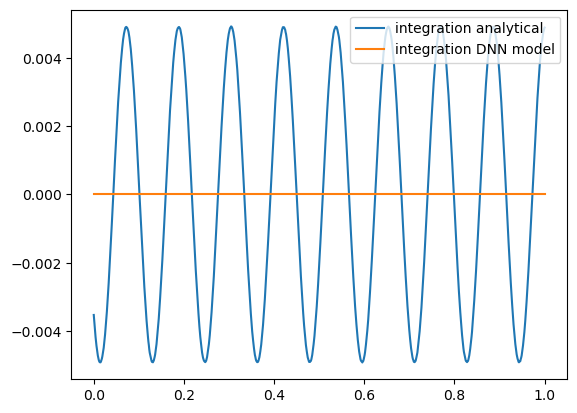

In [36]:
#plt.plot(x, u_t, label = "func")
plt.plot(x, s_t, label = "integration analytical")
plt.plot(x, p, label = "integration DNN model")
plt.legend()

In [37]:
p

array([[8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.52198e-06],
       [8.